In [1]:
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings

In [2]:
load_dotenv()

True

In [3]:
# Define our knowledge base

docs = [
    "Students build production AI systems.",
    "UnlimitedCode is an AI education company.",
    "Our bootcamp teaches AI agents.",
]

# docs = [
#     "UnlimitedCode is an AI education company.",
#     "This is the method of cooking rice and beans",
#     "UnlimitedCode helps you move to the next level in agentic coding",
#     "Blood transfusion helps you get get to your system",
#     "Our bootcamp teaches AI agents."
# ]

In [4]:
# Convert plain strings into LangChain Document objects
documents = [Document(page_content=text) for text in docs]

In [5]:
# Create embedding model
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

In [6]:
# Store documents in ChromaDB vector database

vector_store = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    # persist_directory="./chroma_db"
)
# pinecone, pgvector
print(f"Vector collections created: {vector_store._collection.count()}")

Vector collections created: 3


In [7]:
# Convert vector store into a retriever object

retriever = vector_store.as_retriever(
    search_kwargs={"k":2}
)

In [8]:
query = "What does UnlimitedCode do?"
results = retriever.invoke(query)

In [9]:
print("\nRetrieved Documents:")
for i, doc in enumerate(results, start=0):
    print(f"\nResult {i}:")
    print(doc.page_content)


Retrieved Documents:

Result 0:
UnlimitedCode is an AI education company.

Result 1:
Our bootcamp teaches AI agents.


#### Directly asks the vector database for the most similar documents.

In [10]:
query = "rice cooking methods?"
similar_docs = vector_store.similarity_search(query, k=5)

for i, doc in enumerate(similar_docs):
    print(f"Document {i+1}: \n{doc.page_content}")
    print("\n==========================\n")

Document 1: 
Our bootcamp teaches AI agents.


Document 2: 
Students build production AI systems.


Document 3: 
UnlimitedCode is an AI education company.




#### Know the degree of similarity with score


In [18]:
query = "rice cooking methods?"
results = vector_store.similarity_search_with_score(
    query,
    k=5
)

vector_store.similarity_search_by_vector()

print(results)

[(Document(id='05c57c6d-18b1-4269-ab21-76c75c0ab120', metadata={}, page_content='Our bootcamp teaches AI agents.'), 1.7779864072799683), (Document(id='885513f1-c5b6-4879-80c6-646ab8c924bf', metadata={}, page_content='Students build production AI systems.'), 1.7793903350830078), (Document(id='d0c043b8-a52f-4736-a3b7-f0563b294c8d', metadata={}, page_content='UnlimitedCode is an AI education company.'), 1.8317127227783203)]


In [12]:
for doc, score in results:
    print(f"Score: {score}")
    print(doc.page_content)
    print("-" * 50)

Score: 1.7779864072799683
Our bootcamp teaches AI agents.
--------------------------------------------------
Score: 1.7793903350830078
Students build production AI systems.
--------------------------------------------------
Score: 1.8317127227783203
UnlimitedCode is an AI education company.
--------------------------------------------------


### Visualization

In [13]:
collection = vector_store._collection
results = collection.get()
print(results)

{'ids': ['885513f1-c5b6-4879-80c6-646ab8c924bf', 'd0c043b8-a52f-4736-a3b7-f0563b294c8d', '05c57c6d-18b1-4269-ab21-76c75c0ab120'], 'embeddings': None, 'documents': ['Students build production AI systems.', 'UnlimitedCode is an AI education company.', 'Our bootcamp teaches AI agents.'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [None, None, None]}


In [14]:
results = collection.get(include=["embeddings"])
print(results)
# print(len(results["embeddings"]))
print(len(results["embeddings"][0]))
print(results["embeddings"][1])

{'ids': ['885513f1-c5b6-4879-80c6-646ab8c924bf', 'd0c043b8-a52f-4736-a3b7-f0563b294c8d', '05c57c6d-18b1-4269-ab21-76c75c0ab120'], 'embeddings': array([[ 0.00058174,  0.00040054,  0.03488159, ..., -0.01123047,
         0.00578308,  0.01168823],
       [ 0.01390839, -0.02545166,  0.00279617, ..., -0.03540039,
        -0.0186615 ,  0.02963257],
       [-0.05410767,  0.01351929,  0.05123901, ...,  0.02206421,
        -0.01313782,  0.01818848]], shape=(3, 1536)), 'documents': None, 'uris': None, 'included': ['embeddings'], 'data': None, 'metadatas': None}
1536
[ 0.01390839 -0.02545166  0.00279617 ... -0.03540039 -0.0186615
  0.02963257]


In [15]:
import numpy as np

vectors = np.array(
    collection.get(include=["embeddings"])["embeddings"]
)

print(vectors.shape)


(3, 1536)


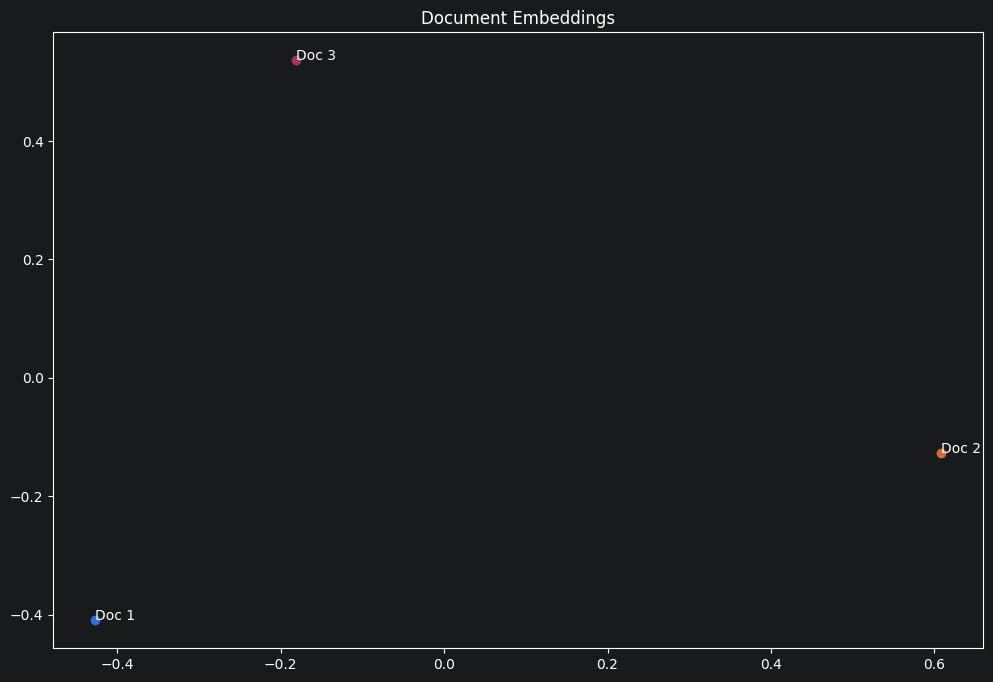

In [16]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data = collection.get(include=["embeddings", "documents"])

vectors = np.array(data["embeddings"])
pca =  PCA(n_components=2)
points = pca.fit_transform(vectors)

plt.figure(figsize=(12,8))

for i, doc in enumerate(data["documents"]):
    plt.scatter(points[i,0], points[i,1])
    plt.annotate(
        f"Doc {i+1}",
        (points[i,0], points[i,1])
    )

plt.title("Document Embeddings")
plt.show()